# Дифракционная нейронная сеть

##### Импорт зависимостей

In [1]:
!pip install --upgrade cvnn
!pip install  tf-keras

In [2]:
import os
import warnings
import string
import tensorflow as tf
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.gridspec import GridSpec

from PIL import Image
from IPython.display import display
import tensorflow_datasets as tfds
import cvnn.layers as complex_layers

from tensorflow import keras
from keras.datasets import fashion_mnist

tfds.disable_progress_bar()

from tensorflow.keras.models import Model
from tensorflow.keras.losses import Loss
from tensorflow.keras.layers import Layer,Lambda,InputLayer
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.constraints import Constraint
from tensorflow.data.experimental import copy_to_device



warnings.filterwarnings('ignore')

2025-05-24 14:36:38.089999: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748097398.359124    1406 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748097398.436358    1406 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        device = '/GPU:0'
        print("✅ Используется GPU:", gpus[0])
    except RuntimeError as e:
        print("⚠️ Не удалось настроить GPU:", e)
        device = '/CPU:0'
else:
    print("❌ GPU не найден. Используется CPU.")
    device = '/CPU:0'

❌ GPU не найден. Используется CPU.


2025-05-24 14:36:52.275631: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
colors = {
      'train': '#4F518C',
      'val': '#CD5334',
      'loss': '#4F518C',
      'acc': '#09814A',
      'bg': '#FFFFFF',
      'grid': '#d9d9d9'
}

params = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "font.size": 14,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.figsize": (13, 5.5),
    "figure.dpi": 300,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,
    "axes.titlepad": 14
}

#### Параметры

In [5]:
LAYER_SIZE = 200
BUFFER_SIZE = 1000
BATCH_SIZE = 16
UP_SAMPLING_SIZE = 140

learning_rate = 0.001
epochs = 4

DATASET_NAME = 'mnist'

#### Загружаем данные

In [6]:
datasets, info = tfds.load(name=DATASET_NAME, with_info=True, as_supervised=True, data_dir='./data')

mnist_train, mnist_test = datasets['train'], datasets['test']

num_train = info.splits['train'].num_examples
num_test = info.splits['test'].num_examples

num_classes = info.features['label'].num_classes
class_names = info.features['label'].names

NUM_CLASSES = num_classes

print(f"Размер тренировочных данных: {num_train}")
print(f"Размер тестовых данных: {num_test}")
print(f"Число классов: {num_classes}")

Размер тренировочных данных: 60000
Размер тестовых данных: 10000
Число классов: 10


In [7]:
def preprocess(image, label):
    # Конвертируем лейблы классов
    label = tf.one_hot(tf.cast(label, tf.int32), num_classes)

    # Увеличиваем размер картинки
    padding_size = (LAYER_SIZE - UP_SAMPLING_SIZE)//2
    image = tf.cast(image, tf.float32)

    up_sampling_image = tf.image.resize(image,
                                        size=[UP_SAMPLING_SIZE, UP_SAMPLING_SIZE],
                                        method='nearest')
    up_sampling_image = up_sampling_image / 255.0 / 2.0

    # Создаем фазовый объект
    phase_image = tf.math.exp(2*np.pi*1j*tf.cast(up_sampling_image,dtype=tf.complex64))

    # Паддинг
    zero_padded_image = tf.pad(phase_image,
                                paddings=[[padding_size,padding_size],[padding_size,padding_size],[0,0]],
                                mode="CONSTANT",constant_values=0)

    return tf.cast(zero_padded_image, dtype=tf.complex64), label

Подготовка датасета:

In [8]:
train_dataset = mnist_train.map(preprocess).cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
test_dataset = mnist_test.map(preprocess).batch(BATCH_SIZE)

print(f"Число батчей в тренировочной выборки: {len(train_dataset)}")
print(f"Число батчей в тестовой выборки: {len(test_dataset)}")

Число батчей в тренировочной выборки: 3750
Число батчей в тестовой выборки: 625


###### Визуализация

In [9]:
def visualize_phase_distribution(dataset, class_names, rows=3, cols=6, save_path=None):
    # Устанавливаем доступный стиль
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update(params)

    # Создаем сетку с правильным расположением элементов
    fig = plt.figure(figsize=(cols*2.0 + 1, rows*2.5))  # +1 для цветовой шкалы
    gs = GridSpec(rows, cols + 1, figure=fig, width_ratios=[1]*cols + [0.1])

    # Основные оси для изображений
    axes = [fig.add_subplot(gs[i//cols, i%cols]) for i in range(rows*cols)]

    # Ось для цветовой шкалы
    cax = fig.add_subplot(gs[:, -1])

    # Получение данных
    for batch_idx, (images, labels) in enumerate(dataset.take(1)):
        images = images.numpy()
        labels = tf.argmax(labels, axis=1).numpy()

        num_images = min(len(images), rows*cols)

        # Визуализация изображений
        for idx in range(num_images):
            ax = axes[idx]
            phase = np.angle(images[idx]).squeeze()
            #phase_rotated = np.rot90(phase, k=-1)
            #phase =  np.fliplr(phase_rotated)
            label = class_names[labels[idx]] if labels[idx] < len(class_names) else '?'

            im = ax.imshow(phase % (2*np.pi),
                          cmap='viridis',
                          vmin=0,
                          vmax=2*np.pi,
                          interpolation='none')

            ax.set_title(f'Класс: {label}', fontsize=9, pad=4)
            ax.axis('off')

        # Скрытие пустых осей
        for idx in range(num_images, len(axes)):
            axes[idx].axis('off')

    # Настройка цветовой шкалы
    cbar = fig.colorbar(im, cax=cax, orientation='vertical')
    cbar.set_label('Фаза', rotation=270, labelpad=20, fontsize=10)
    cbar.set_ticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    cbar.set_ticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

    # Общий заголовок
    plt.suptitle('Фазовое распределение',
                y=0.95,
                fontsize=12,
                fontweight='bold')

    # Финализация layout
    plt.tight_layout(pad=1.0)
    plt.subplots_adjust(right=0.88)  # Место для цветовой шкалы

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

Посмотрим, какие лейблы:

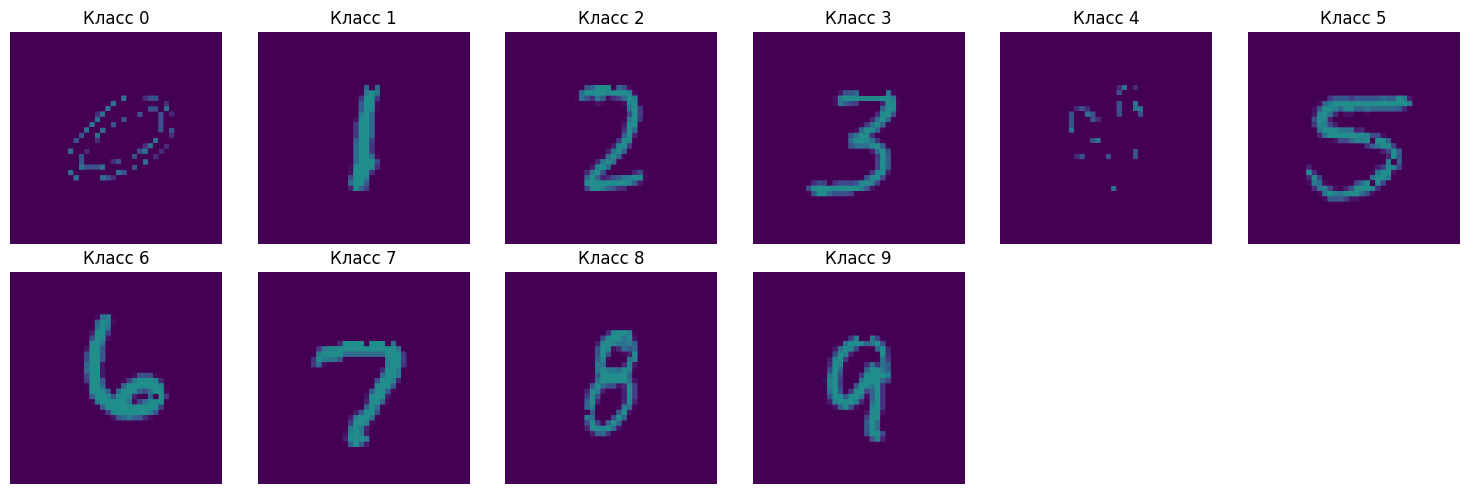

In [10]:
def decode_label(one_hot):
    return tf.argmax(one_hot).numpy()

examples = {}

for image_batch, label_batch in train_dataset.unbatch():
    label_idx = decode_label(label_batch)
    if label_idx not in examples:
        examples[label_idx] = image_batch
    if len(examples) == num_classes:
        break

data = []
for label, image in sorted(examples.items()):
    phase = np.angle(image.numpy().squeeze())
    #phase_rotated = np.rot90(phase, k=-1)
    #phase =  np.fliplr(phase_rotated)
    data.append({
        "Лейбл": label,
        "Изображение": phase
    })

df = pd.DataFrame(data)

cols = 6
rows = int(np.ceil(len(df) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2.5*rows))

for i, (idx, row) in enumerate(df.iterrows()):
    ax = axes[i // cols, i % cols]
    ax.imshow(row["Изображение"], cmap='viridis', vmin=0, vmax=2*np.pi)
    ax.set_title(f"Класс {row['Лейбл']}")
    ax.axis("off")

for j in range(i + 1, rows * cols):
    axes[j // cols, j % cols].axis('off')

plt.tight_layout()
plt.show()

### Обработанные данные

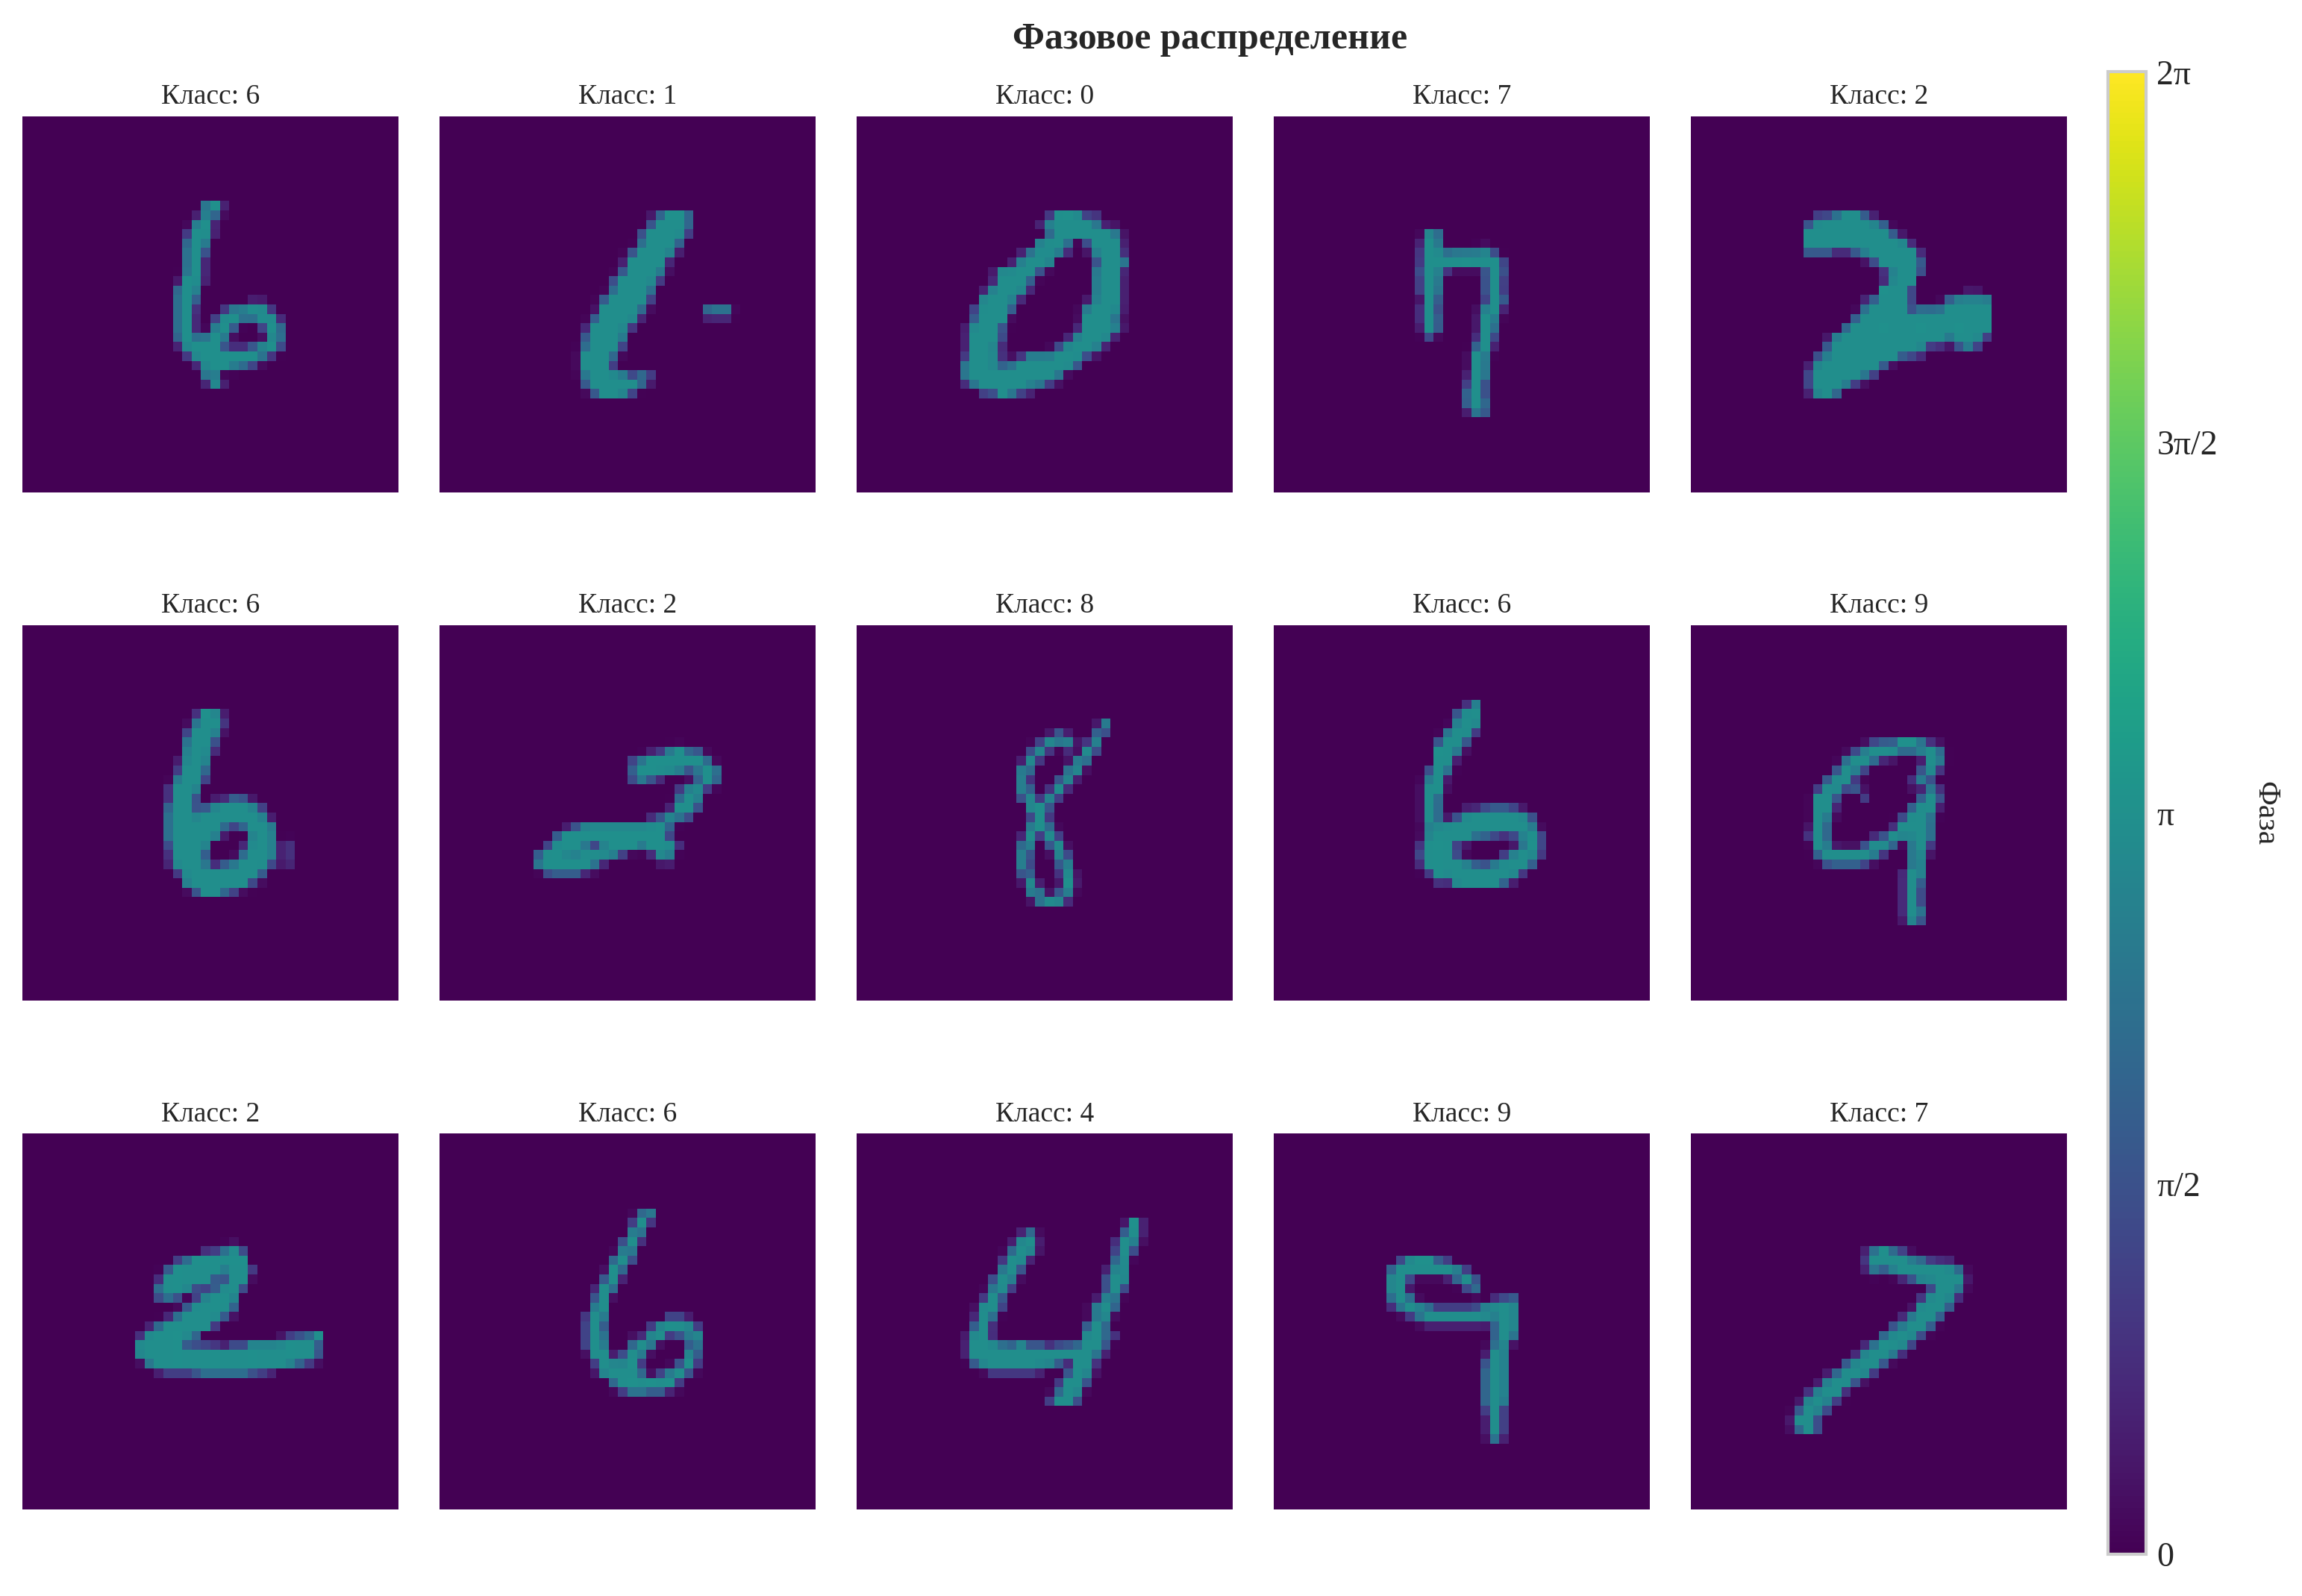

In [11]:
class_num_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
#class_names = #['-']# + list(string.ascii_uppercase) + class_num_names
class_names = class_num_names
visualize_phase_distribution(train_dataset.shuffle(30),
                            class_names,
                            rows=3,
                            cols=5,
                            save_path='phase_distribution.png')

Отфильтруем датасет для нужных букв:

In [45]:
target_labels = [13, 6, 20, 9, 16, 11, 18, 19, 21, 15, 26, 22]
num_classes = len(target_labels) ## ДЛЯ PREPROCESS
class_names = [string.ascii_uppercase[i - 1] for i in target_labels]
print(class_names)

['M', 'F', 'T', 'I', 'P', 'K', 'R', 'S', 'U', 'O', 'Z', 'V']
Число cтрок тренировочной выборки: 41015
Число строк тестовой выборки: 6000


In [47]:
label_map = {orig: i for i, orig in enumerate(target_labels)}

keys_tensor = tf.constant(target_labels, dtype=tf.int64)
vals_tensor = tf.range(len(target_labels), dtype=tf.int64)

label_table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys_tensor, vals_tensor),
    default_value=-1
)

def filter_and_remap(image, label):
    new_label = label_table.lookup(tf.cast(label, tf.int64))
    keep = tf.not_equal(new_label, -1)
    return keep

def remap_label(image, label):
    new_label = label_table.lookup(tf.cast(label, tf.int64))
    return image, new_label

filtered_train = mnist_train.filter(filter_and_remap).map(remap_label)
filtered_test = mnist_test.filter(filter_and_remap).map(remap_label)

f_train_dataset = (
    filtered_train
    .map(preprocess)
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

f_test_dataset = (
    filtered_test
    .map(preprocess)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [48]:
f_train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 120, 120, 1), dtype=tf.complex64, name=None), TensorSpec(shape=(None, 12), dtype=tf.float32, name=None))>

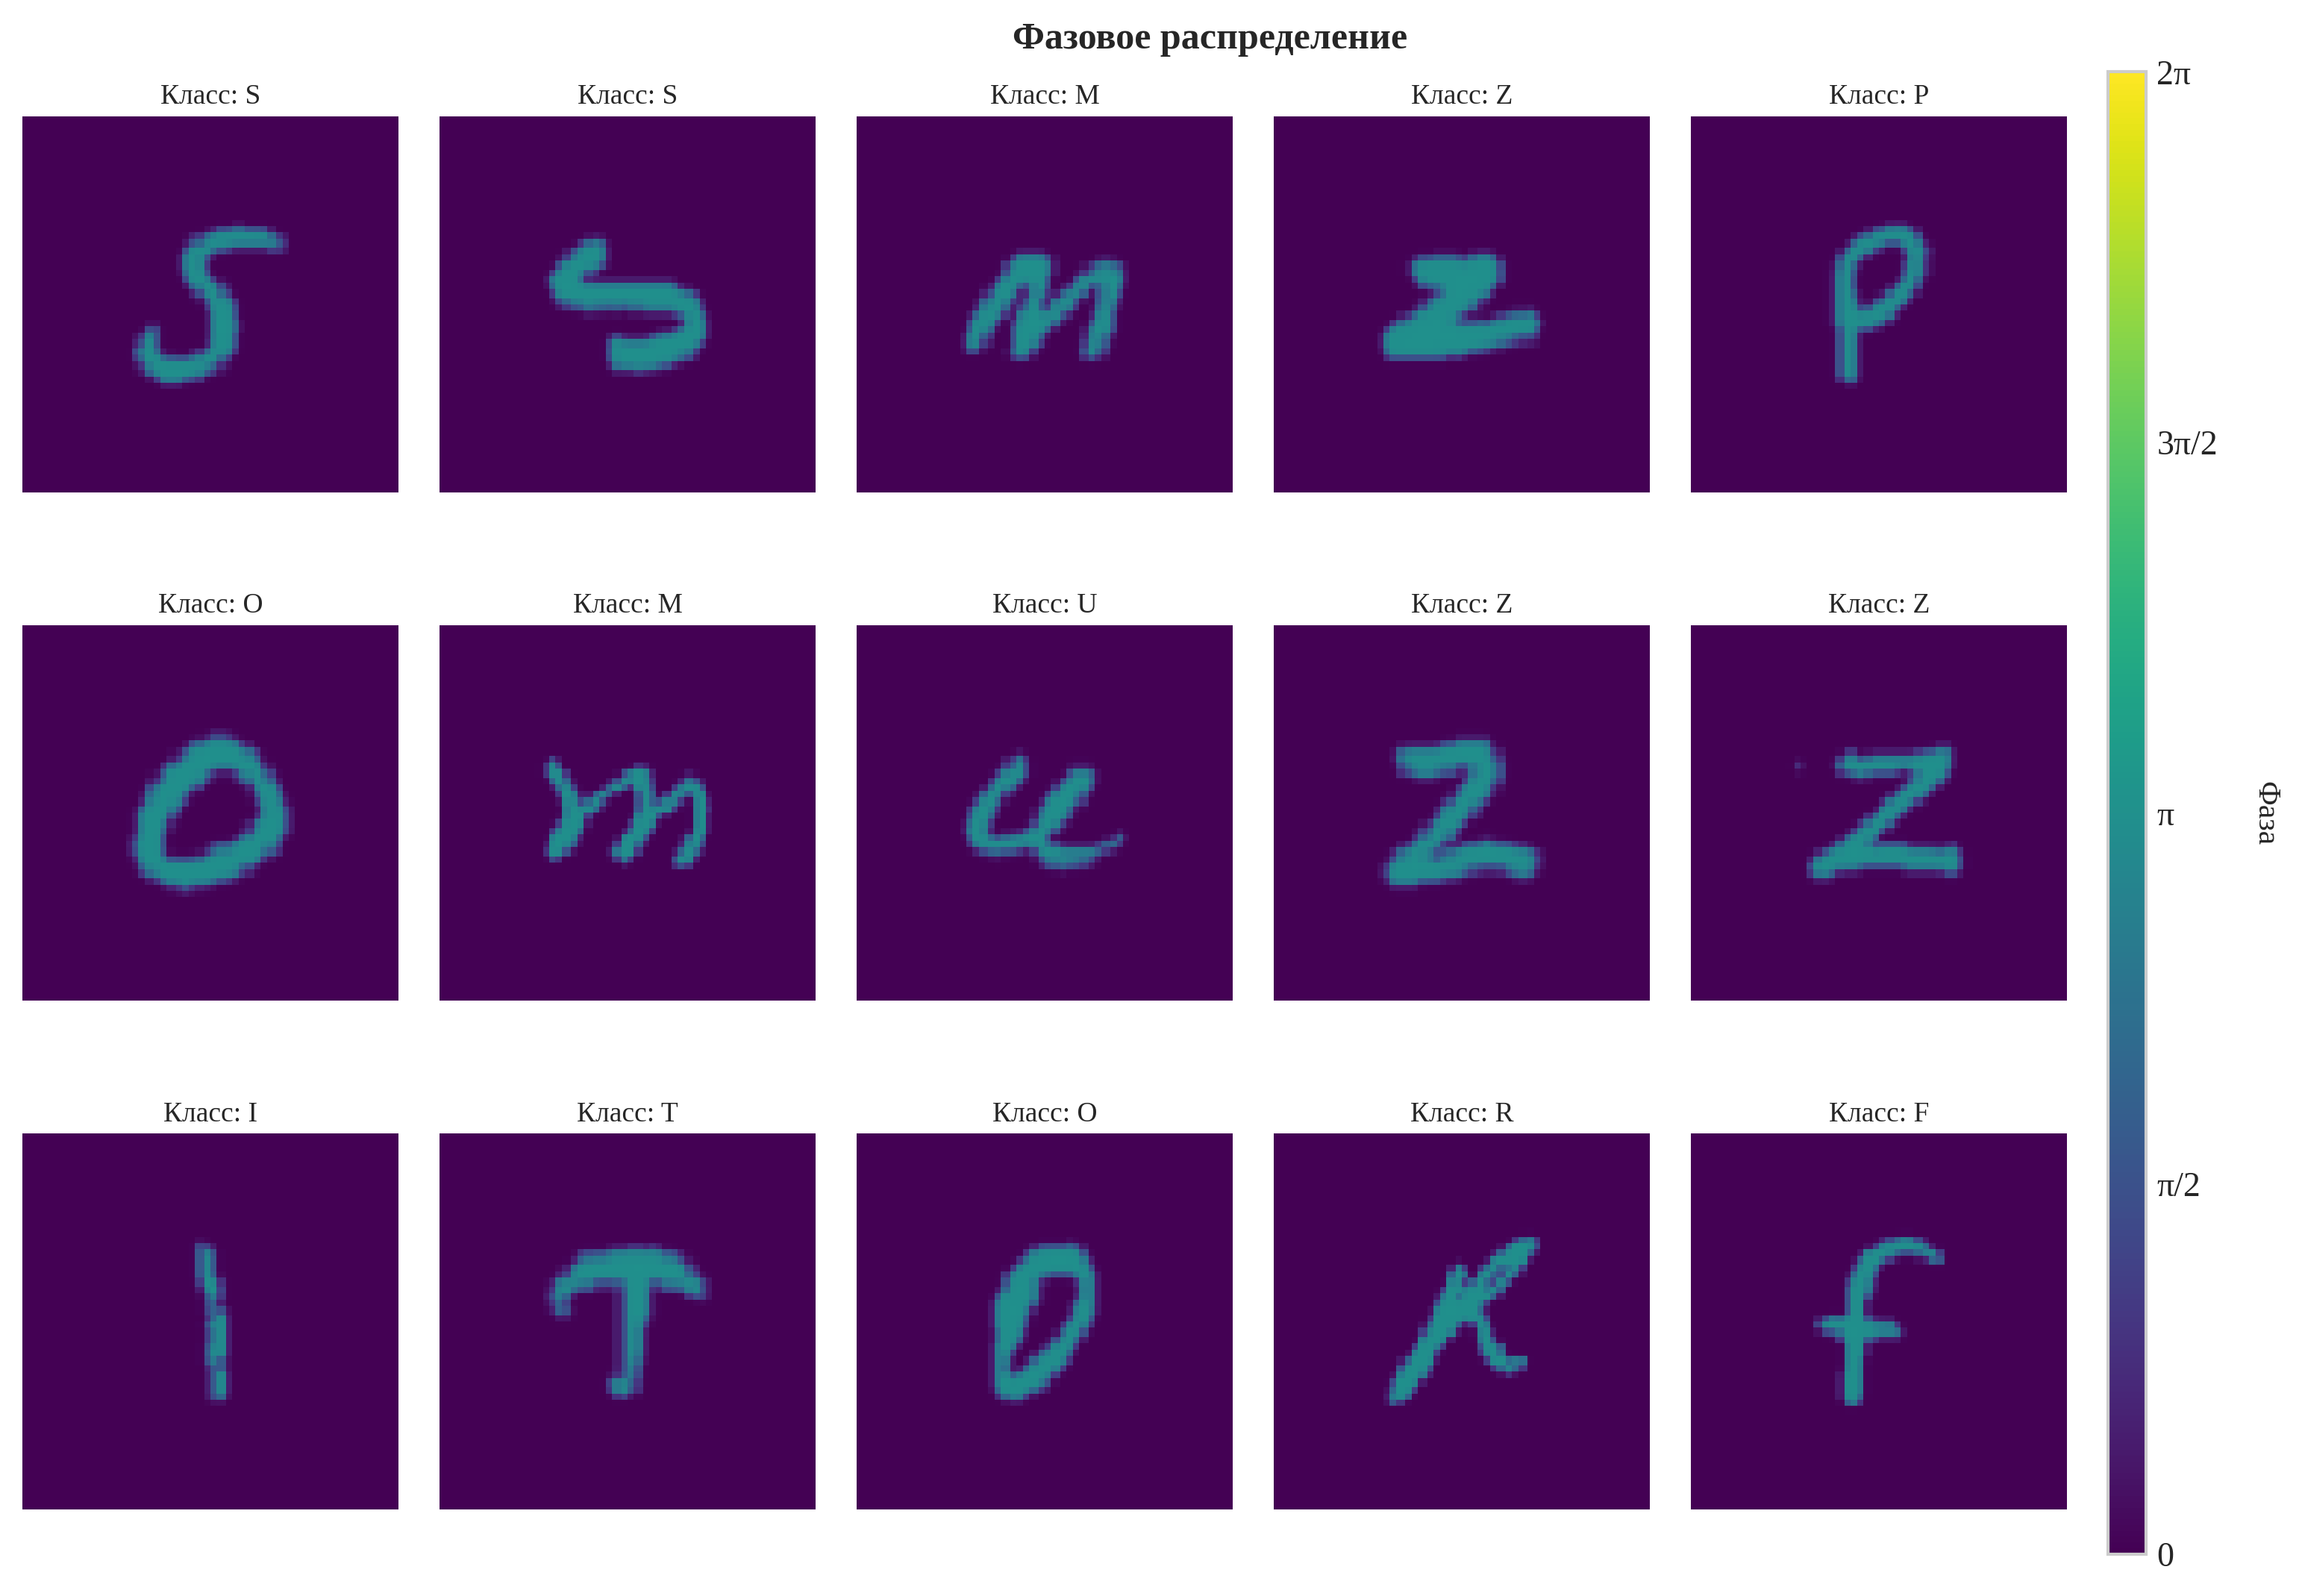

In [49]:
visualize_phase_distribution(f_train_dataset.shuffle(30),
                            class_names,
                            rows=3,
                            cols=5,
                            save_path='phase_distribution_f.png')

Для цифр **MNIST**:

In [12]:
f_train_dataset = train_dataset
f_test_dataset = test_dataset
num_classes = 10

## Класс дифракционной сети
`ClipPhase` для обрезки фаз в решетках до $2\pi$

In [13]:
class ClipPhase(Constraint):
    def __init__(self, min_value=0.0, max_value=2* tf.constant(np.pi)):
        self.min_value = min_value
        self.max_value = max_value

    def __call__(self, w):
        return tf.math.floormod(w, 2.0 *  tf.constant(np.pi))

    def get_config(self):
        return {"min_value": self.min_value, "max_value": self.max_value}

Основной класс дифракционной сети `Diffraction_Layer`. На вход подаётся оптическое поле inputs (в виде 2D-сетки амплитуд), к нему применяется дифракционное распространение, после чего результат умножается на **фазовую маску** текущего слоя

In [14]:
class Diffraction_Layer(Layer):
    def __init__(self, units=200):
        super().__init__()
        self.units = units
        self.Nx = units
        self.dx = tf.Variable(100e-6, dtype=tf.float32, trainable=False)
        self.lam = tf.Variable(0.75e-3, dtype=tf.float32, trainable=False)
        self.z = tf.Variable(3e-2, dtype=tf.float32, trainable=False)


    def build(self, shape):
        phase_init = tf.random_uniform_initializer(minval=0, maxval=tf.constant(np.pi))
        self.phase = self.add_weight(
            name="phase",
            shape=(self.units, self.units),
            initializer=phase_init,
            trainable=True,
            constraint=ClipPhase()
        )


    def angular_spectrum_propagator(self, E):
        Nx = self.Nx
        dx = self.dx
        lam = self.lam
        z = self.z

        # FFT
        E_fft = tf.signal.fft2d(E)
        E_fft = tf.signal.fftshift(E_fft)

        # Частотная сетка
        fx = tf.linspace(-0.5 / dx, 0.5 / dx, Nx)
        fxx, fyy = tf.meshgrid(fx, fx)
        fxx = tf.cast(fxx, tf.float32)
        fyy = tf.cast(fyy, tf.float32)

        # k и аргумент
        k = tf.constant(1.0, dtype=tf.float32) / lam
        arg = tf.square(k) - tf.square(fxx) - tf.square(fyy)

        # kz: вещественная и мнимая части
        sqrt_arg = tf.sqrt(tf.abs(arg))
        kz_real = tf.where(arg >= 0.0, sqrt_arg, tf.zeros_like(sqrt_arg))
        kz_imag = tf.where(arg < 0.0, sqrt_arg, tf.zeros_like(sqrt_arg))

        kz = tf.complex(kz_real, kz_imag)
        H = tf.exp(1j * kz * tf.cast(z, tf.complex64))

        # Обратный сдвиг и обратное FFT
        propagated = tf.signal.ifft2d(tf.signal.ifftshift(E_fft * H))

        return propagated

    @tf.function
    def call(self, inputs):
        phase_mod = tf.exp(1j * tf.cast(self.phase, tf.complex64))
        return self.angular_spectrum_propagator(inputs) * phase_mod

Класс `Propogation` представляет собой слой, моделирующий свободное распространение оптического поля без фазовой модуляции. Он обёртывает слой `Diffraction_Layer` и использует только его функцию дифракционного распространения методом углового спектра.

In [15]:
class Propogation(Layer):
    def __init__(self, units=200):
        super(Propogation, self).__init__()
        self.units = units
        self.diff_layer = Diffraction_Layer(units=units)            # Для свободного пространства
        self.diff_layer.trainable = False                           # Отключаем веса

    def build(self, input_shape):
        pass

    @tf.function
    def call(self, inputs):
        return self.diff_layer.angular_spectrum_propagator(inputs)

Класс `Detector` реализует слой, моделирующий оптический детектор, который разбивает входное поле на сетку 2×5 и вычисляет среднюю интенсивность в каждом блоке. Возвращаемый тензор представляет собой логиты (по одному на каждый блок), используемые как выход модели.

In [16]:
class Detector(Layer):
    def __init__(self, num_classes=10, grid_division=None):
        """
        Детектор фазовых признаков для произвольного числа классов
        """
        super(Detector, self).__init__()
        self.num_classes = num_classes

        if grid_division is None:
            self.grid_rows = int(np.ceil(np.sqrt(num_classes)))
            self.grid_cols = int(np.ceil(num_classes / self.grid_rows))
        else:
            self.grid_rows, self.grid_cols = grid_division
            assert self.grid_rows * self.grid_cols >= num_classes, \
                f"Количество блоков ({self.grid_rows*self.grid_cols}) должно быть >= числу классов ({num_classes})"

    def build(self, shape):
      print(f"Детектор инициализирован с числом классов: {num_classes}")
      print(f"Размеры сетки детектора: {self.grid_rows}x{self.grid_cols}")
      pass

    @tf.function
    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        H, W = tf.shape(inputs)[1], tf.shape(inputs)[2]

        # Размеры каждого блока
        hh, ww = H // self.grid_rows, W // self.grid_cols

        regions = []
        for i in range(self.grid_rows):
            for j in range(self.grid_cols):
                block = inputs[:, i*hh:(i+1)*hh, j*ww:(j+1)*ww]
                regions.append(tf.reduce_mean(tf.abs(block), axis=[1,2]))

        # Берем только необходимое количество регионов
        regions = regions[:self.num_classes]

        return tf.stack(regions, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.num_classes)

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_classes': self.num_classes,
            'grid_rows': self.grid_rows,
            'grid_cols': self.grid_cols
        })
        return config

Функция для создания модели:

In [17]:
def get_D2NN_model():
    inputs = complex_layers.complex_input(shape=(LAYER_SIZE, LAYER_SIZE))
    h1 = Diffraction_Layer(LAYER_SIZE)(inputs)
    h2 = Diffraction_Layer(LAYER_SIZE)(h1)
    h3 = Diffraction_Layer(LAYER_SIZE)(h2)
    h4 = Diffraction_Layer(LAYER_SIZE)(h3)
    h5 = Diffraction_Layer(LAYER_SIZE)(h4)
    h6 = Diffraction_Layer(LAYER_SIZE)(h5)
    propogation = Propogation(LAYER_SIZE)(h6)
    out = Detector(num_classes=num_classes)(propogation)
    return tf.keras.Model(inputs, out)

## Обучение

In [18]:
class BatchHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.batch_losses = []
        self.batch_accuracies = []
        self.batch_steps = []

    def on_train_batch_end(self, batch, logs=None):
        self.batch_losses.append(logs.get('loss'))
        self.batch_accuracies.append(logs.get('accuracy'))
        self.batch_steps.append(self.model.optimizer.iterations.numpy())


checkpoint_path = './training_results/orig_mnist.weights.h5'
checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                             save_weights_only=True,
                             monitor="val_loss",
                             save_freq='epoch')

In [19]:
batch_history = BatchHistory()
with tf.device(device):
    D2NN = get_D2NN_model()
    D2NN.summary()
    D2NN.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, weight_decay=1e-6),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = D2NN.fit(f_train_dataset,
                      epochs=epochs,
                      validation_data=f_test_dataset,
                      callbacks=[checkpoint, batch_history])


Детектор инициализирован с числом классов: 10
Размеры сетки детектора: 4x3


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ complex_input (ComplexInput)         │ (None, 200, 200)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ diffraction__layer                   │ (None, 200, 200)            │          40,000 │
│ (Diffraction_Layer)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ diffraction__layer_1                 │ (None, 200, 200)            │          40,000 │
│ (Diffraction_Layer)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ diffraction__layer_2                 │ (None, 200, 200)            │          40,000 │
│ (Diffraction_Layer)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ diffraction__layer_3                 │ (None, 200, 200)            │          40,000 │
│ (Diffraction_Layer)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ diffraction__layer_4                 │ (None, 200, 200)            │          40,000 │
│ (Diffraction_Layer)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ diffraction__layer_5                 │ (None, 200, 200)            │          40,000 │
│ (Diffraction_Layer)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ propogation (Propogation)            │ (None, 200, 200)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ detector (Detector)                  │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 240,000 (937.50 KB)

 Trainable params: 240,000 (937.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 716s 189ms/step - accuracy: 0.5501 - loss: 1.9670 - val_accuracy: 0.8265 - val_loss: 1.3621
Epoch 2/4
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 700s 187ms/step - accuracy: 0.8285 - loss: 1.3037 - val_accuracy: 0.8513 - val_loss: 1.1737
Epoch 3/4
 866/3750 ━━━━━━━━━━━━━━━━━━━━ 8:10 170ms/step - accuracy: 0.8460 - loss: 1.1786

KeyboardInterrupt: 

### Графики

In [ ]:
def plot_training(history, save_path=None):

    sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.6})
    plt.rcParams.update(params)


    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_facecolor(colors['bg'])

    # --- График Loss ---
    ax1.plot(epochs, loss, label='Ошибка на обучении', marker='o',
             color=colors['train'], markeredgecolor='white', markeredgewidth=1)
    ax1.plot(epochs, val_loss, label='Ошибка на валидации', marker='s',
             linestyle='--', color=colors['val'], markeredgecolor='white', markeredgewidth=1)

    ax1.set_title('Функция потерь', pad=15)
    ax1.set_xlabel('Эпоха')
    ax1.set_ylabel('Значение функции потерь')
    ax1.legend(framealpha=0.9, facecolor='white')
    ax1.grid(color=colors['grid'])
    ax1.set_facecolor(colors['bg'])

    # --- График Accuracy ---
    ax2.plot(epochs, acc, label='Точность на обучении', marker='o',
             color=colors['train'], markeredgecolor='white', markeredgewidth=1)
    ax2.plot(epochs, val_acc, label='Точность на валидации', marker='s',
             linestyle='--', color=colors['val'], markeredgecolor='white', markeredgewidth=1)

    ax2.set_title('Точность предсказаний', pad=15)
    ax2.set_xlabel('Эпоха')
    ax2.set_ylabel('Точность')
    ax2.legend(framealpha=0.9, facecolor='white')
    ax2.grid(color=colors['grid'])
    ax2.set_facecolor(colors['bg'])

    # Общий заголовок
    fig.suptitle('Динамика обучения D2NN модели', fontsize=16, y=0.98,
                fontweight='bold', color='#2a2a2a')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()


def plot_batch_training(batch_history, save_path=None):
    sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.6})
    plt.rcParams.update(params)


    steps = batch_history.batch_steps
    losses = batch_history.batch_losses
    accuracies = batch_history.batch_accuracies

    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_facecolor(colors['bg'])

    # --- График Loss ---
    ax1.plot(steps, losses, color=colors['loss'], label='Потери на батче',
             linewidth=2.5, alpha=0.9)
    ax1.set_xlabel("Шаг обучения")
    ax1.set_ylabel("Значение потерь")
    ax1.set_title("Динамика потерь", pad=15)
    ax1.legend(framealpha=0.9, facecolor='white')
    ax1.grid(color=colors['grid'])
    ax1.set_facecolor(colors['bg'])

    # --- График Accuracy ---
    ax2.plot(steps, accuracies, color=colors['acc'], label='Точность на батче',
             linewidth=2.5, alpha=0.9)
    ax2.set_xlabel("Шаг обучения")
    ax2.set_ylabel("Точность")
    ax2.set_title("Динамика точности", pad=15)
    ax2.legend(framealpha=0.9, facecolor='white')
    ax2.grid(color=colors['grid'])
    ax2.set_facecolor(colors['bg'])

    # Общий заголовок
    fig.suptitle('Прогресс обучения на уровне батчей', fontsize=16, y=0.98,
                fontweight='bold', color='#2a2a2a')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

Посмотрим, что получилось

In [ ]:
plot_training(history, "training_results_epoch")
plot_batch_training(batch_history, "training_results_baches")

In [28]:
## Точность модели на других $\lambda$

Загрузим получившуюся модель:

In [20]:
model = get_D2NN_model()
checkpoint_path = './training_results/orig_mnist.weights.h5'
model.load_weights(checkpoint_path)

Детектор инициализирован с числом классов: 10
Размеры сетки детектора: 4x3


In [21]:
def evaluate_model_on_lambda(D2NN, lam_value, test_dataset):

    for layer in D2NN.layers:
        if isinstance(layer, Diffraction_Layer):
            layer.lam.assign(tf.constant(lam_value, dtype=tf.float32))
        elif isinstance(layer, Propogation):
            layer.diff_layer.lam.assign(tf.constant(lam_value, dtype=tf.float32))

    loss, acc = D2NN.evaluate(test_dataset, verbose=0)
    return acc

In [22]:
lambda_list = np.linspace(0.7e-3, 0.8e-3, num=25).tolist()
lambda_results = {}

In [23]:
with tqdm(lambda_list, desc="Различные длины волн", unit="λ") as pbar:
    for lam in pbar:
        acc = evaluate_model_on_lambda(D2NN, lam, f_test_dataset)
        lambda_results[lam] = acc
        print(f"λ = {lam*1e3:.2f} мм → Accuracy: {acc:.4f}")

Различные длины волн:   4%|▍         | 1/25 [00:54<21:51, 54.66s/λ]

λ = 0.70 мм → Accuracy: 0.3461


Различные длины волн:   8%|▊         | 2/25 [01:50<21:09, 55.21s/λ]

λ = 0.70 мм → Accuracy: 0.3846


Различные длины волн:  12%|█▏        | 3/25 [02:45<20:14, 55.21s/λ]

...

λ = 0.79 мм → Accuracy: 0.4460


Различные длины волн:  96%|█████████▌| 24/25 [22:36<00:58, 58.10s/λ]

λ = 0.80 мм → Accuracy: 0.3959


Различные длины волн: 100%|██████████| 25/25 [23:30<00:00, 56.40s/λ]

λ = 0.80 мм → Accuracy: 0.3459


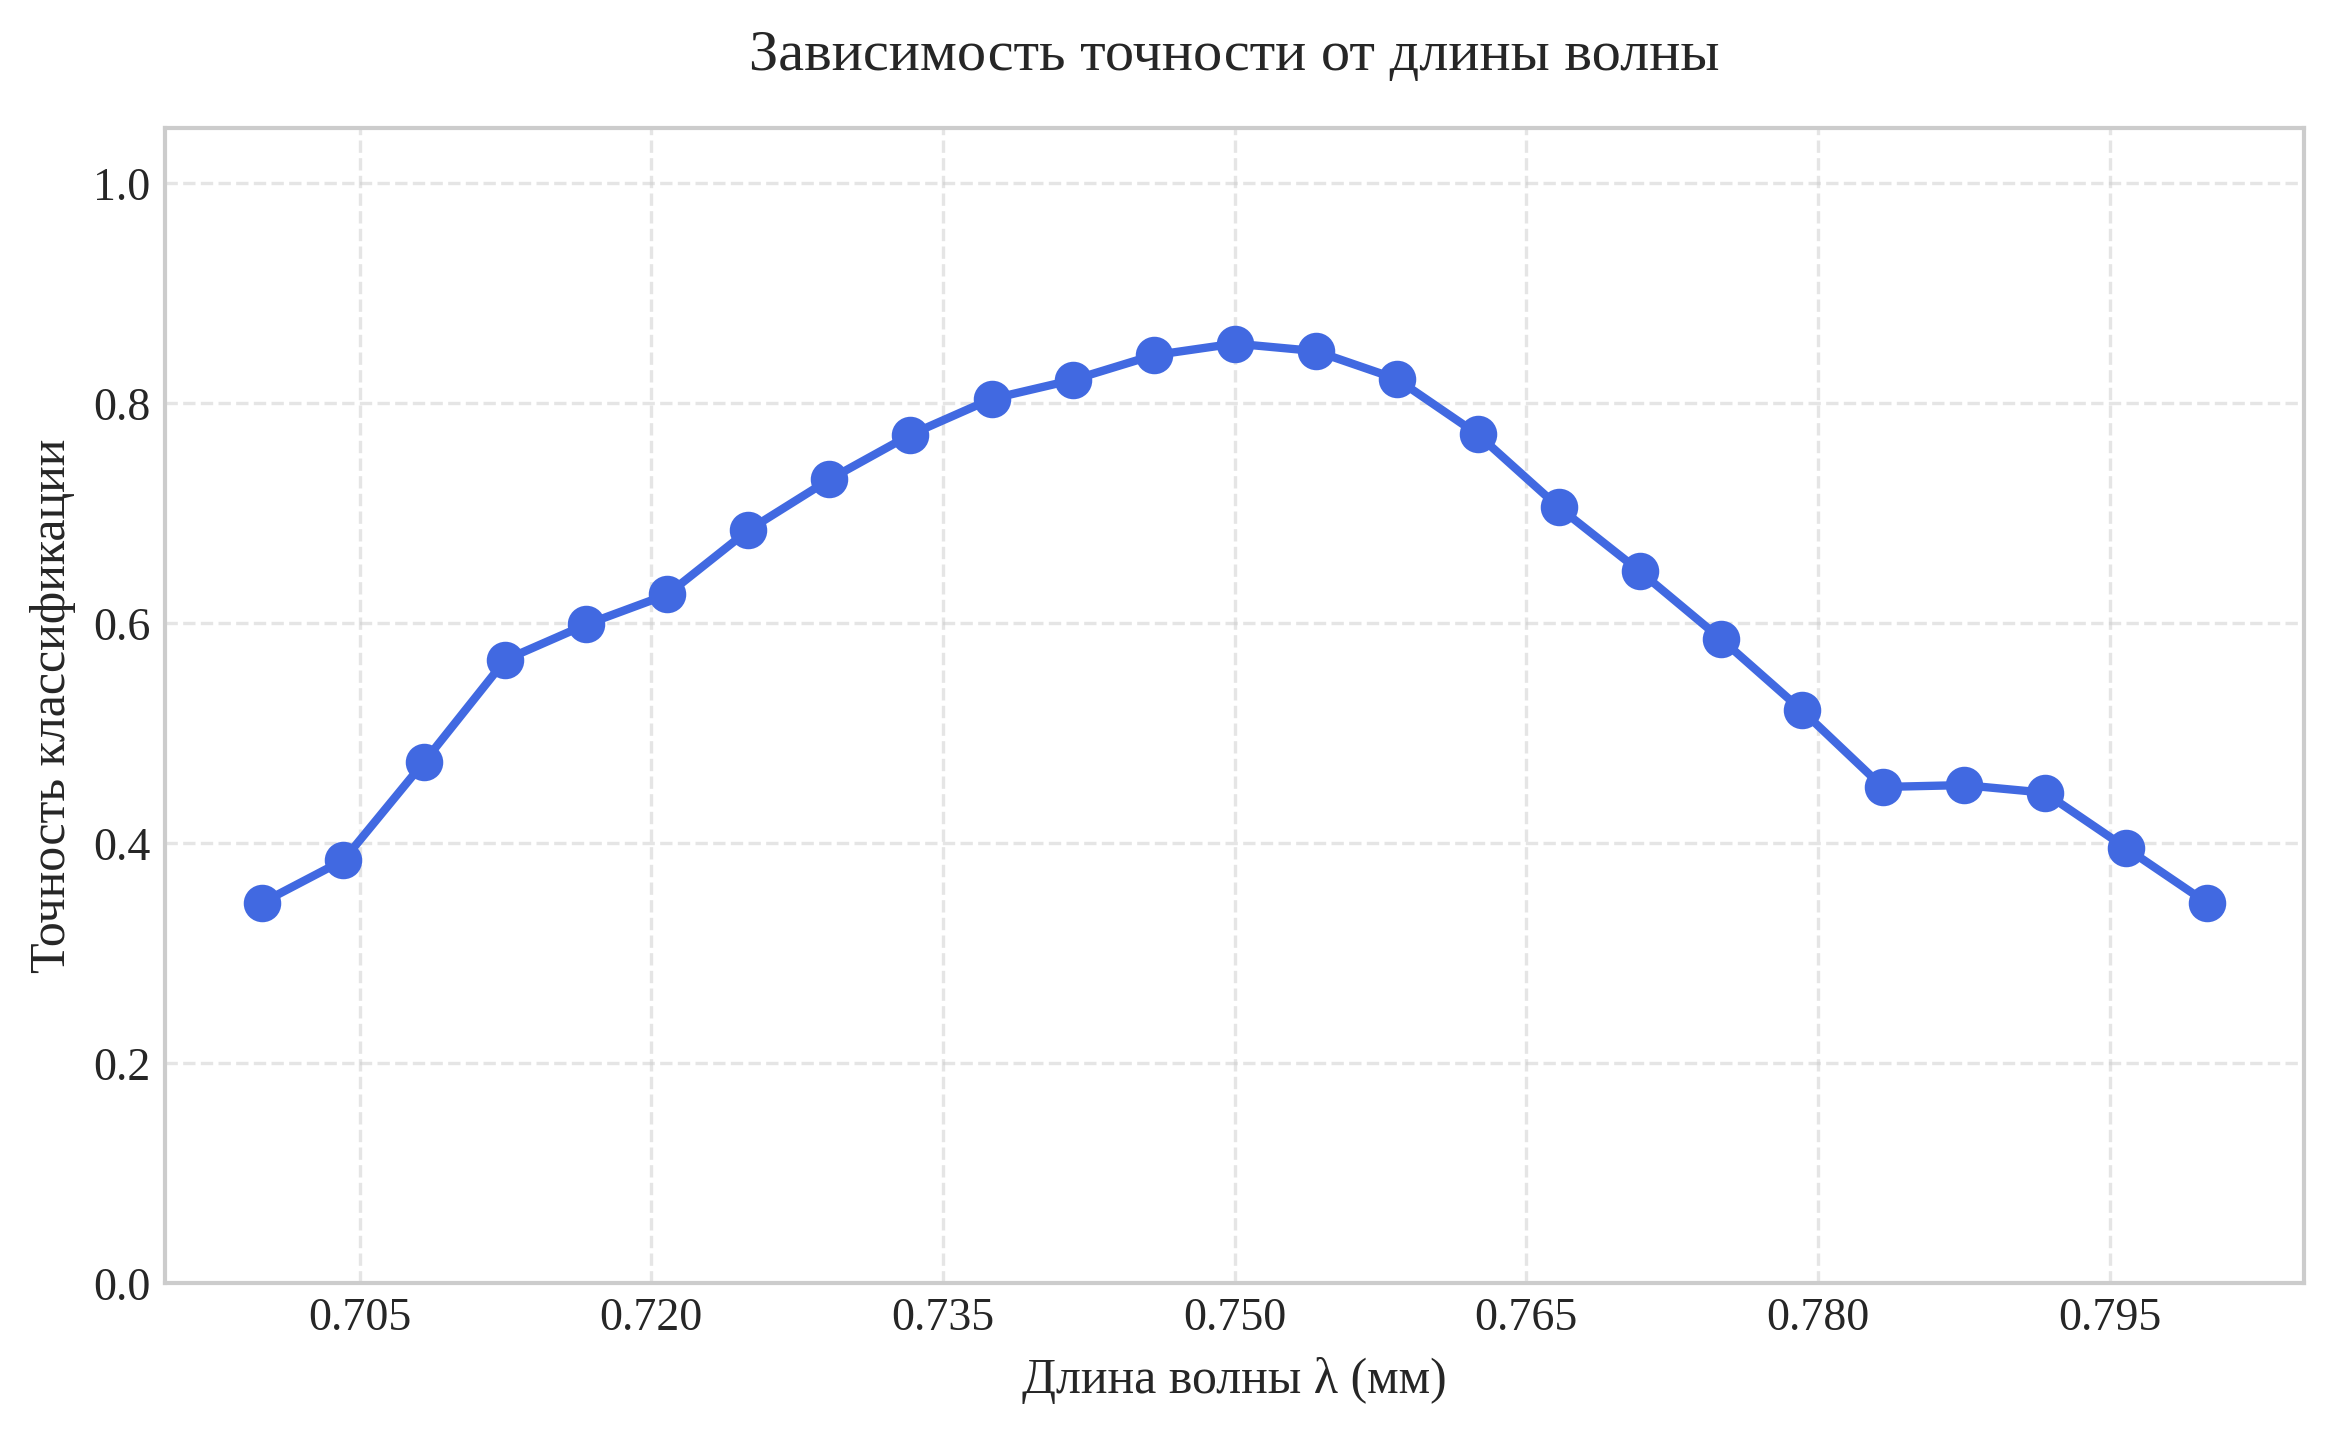

<Figure size 3900x1650 with 0 Axes>

In [37]:
lambda_mm = [lam * 1e3 for lam in lambda_results.keys()]
accuracies = list(lambda_results.values())

plt.figure(figsize=(8, 5))
plt.plot(lambda_mm, accuracies, marker='o', linestyle='-', color='royalblue', linewidth=2)


plt.title('Зависимость точности от длины волны', fontsize=14)
plt.xlabel('Длина волны λ (мм)', fontsize=12)
plt.ylabel('Точность классификации', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=10))
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()
plt.savefig("lambda_acc.png", dpi=300, bbox_inches='tight')

In [38]:
def evaluate_with_relative_noise(base_model, test_dataset, percent_noise_list):
    results = {}

    for percent in percent_noise_list:
        # Клонируем модель и копируем веса
        model = get_D2NN_model()
        model.set_weights(base_model.get_weights())

        # Вносим относительный шум в фазовые маски
        for layer in model.layers:
            if hasattr(layer, "phase"):
                phase = layer.phase.numpy()
                
                # Процентный шум: std = percent * |phi|
                std_matrix = np.abs(phase) * percent
                noise = np.random.normal(loc=0.0, scale=std_matrix)
                
                # Добавляем шум, обрезаем в диапазон [0, 2π]
                noisy_phase = (phase + noise) % (2 * np.pi)
                layer.phase.assign(noisy_phase.astype(np.float32))

        model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
        loss, acc = model.evaluate(test_dataset, verbose=0)
        results[percent] = acc
        print(f"Шум {percent*100:.1f}% от значения фазы → Accuracy: {acc:.4f}")

    return results

In [39]:
percent_levels = np.linspace(0.0, 1, num=25).tolist()
relative_noise_results = evaluate_with_relative_noise(model, f_test_dataset, percent_levels)

Детектор инициализирован с числом классов: 10
Размеры сетки детектора: 4x3
Шум 0.0% от значения фазы → Accuracy: 0.8513
Детектор инициализирован с числом классов: 10
Размеры сетки детектора: 4x3
Шум 4.2% от значения фазы → Accuracy: 0.8512
Детектор инициализирован с числом классов: 10
Размеры сетки детектора: 4x3
Шум 8.3% от значения фазы → Accuracy: 0.8482
Детектор инициализирован с числом классов: 10
Размеры сетки детектора: 4x3
Шум 12.5% от значения фазы → Accuracy: 0.8455
Детектор инициализирован с числом классов: 10
Размеры сетки детектора: 4x3
Шум 16.7% от значения фазы → Accuracy: 0.8434
Детектор инициализирован с числом классов: 10
Размеры сетки детектора: 4x3
Шум 20.8% от значения фазы → Accuracy: 0.8386
Детектор инициализирован с числом классов: 10
Размеры сетки детектора: 4x3
Шум 25.0% от значения фазы → Accuracy: 0.8517
Детектор инициализирован с числом классов: 10
Размеры сетки детектора: 4x3
Шум 29.2% от значения фазы → Accuracy: 0.8066
Детектор инициализирован с числом к

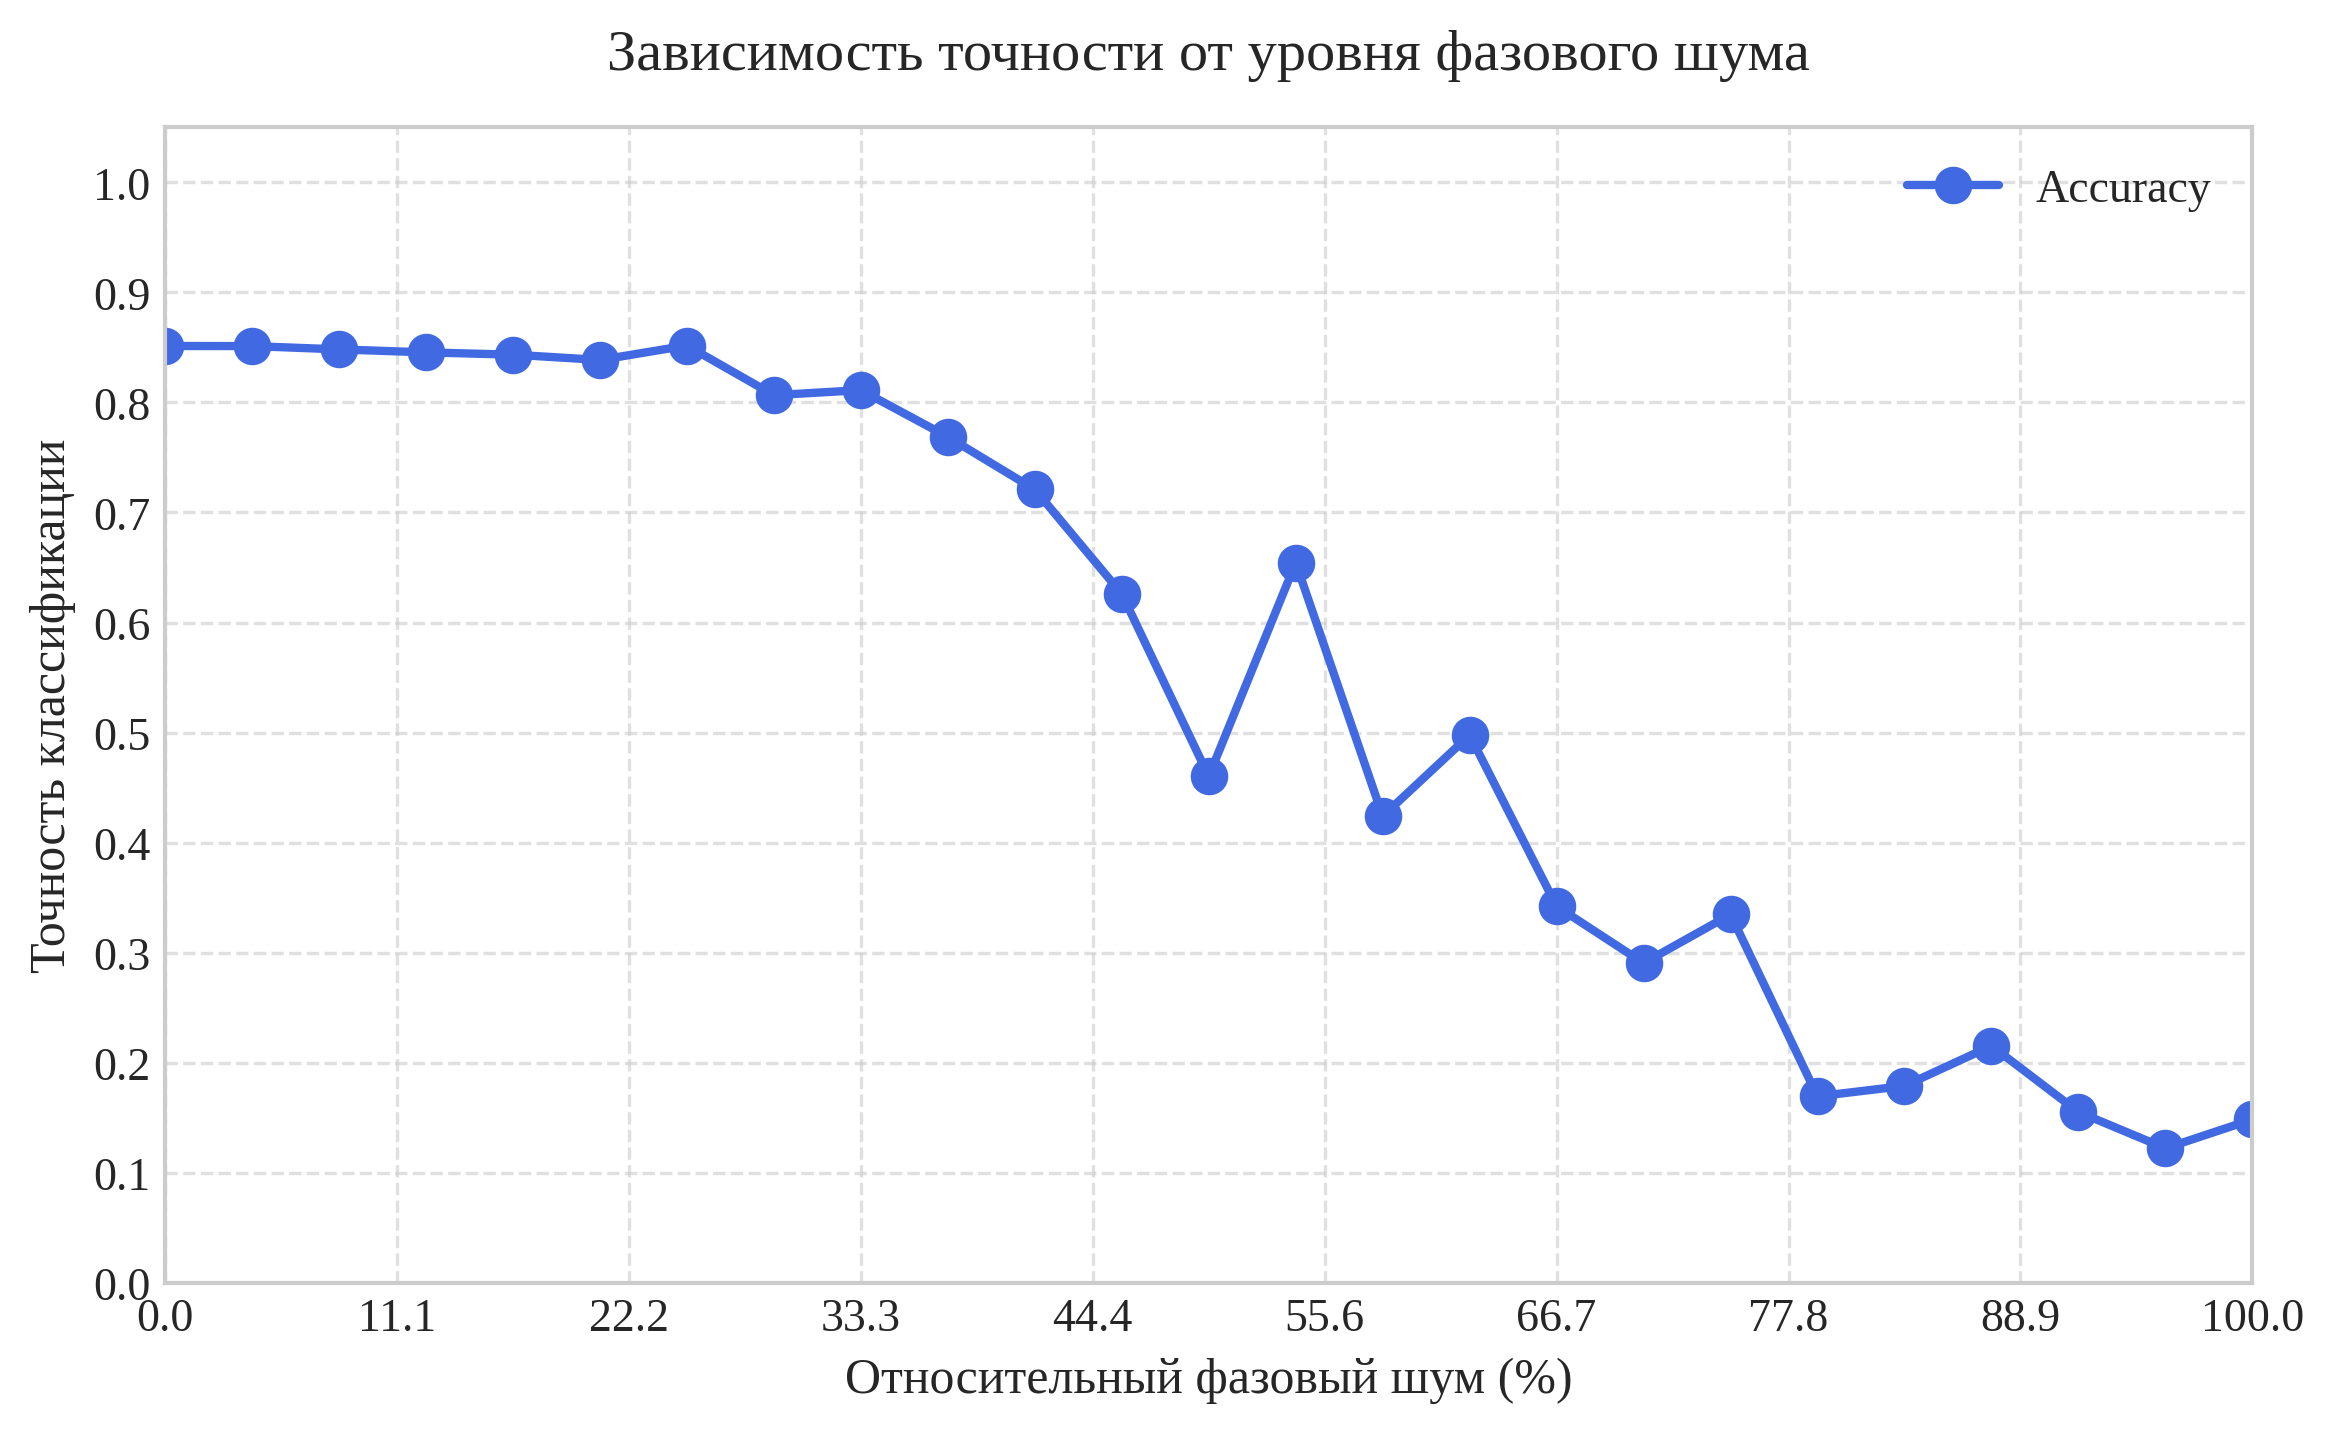

<Figure size 3900x1650 with 0 Axes>

In [41]:
x = [p * 100 for p in relative_noise_results.keys()]
y = list(relative_noise_results.values())

# Построение графика
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o', linewidth=2, color='royalblue', label='Accuracy')

# Оформление
plt.title("Зависимость точности от уровня фазового шума", fontsize=14)
plt.xlabel("Относительный фазовый шум (%)", fontsize=12)
plt.ylabel("Точность классификации", fontsize=12)
plt.ylim(0, 1.05)
plt.xlim(0, max(x))
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.xticks(np.linspace(0, max(x), 10))
plt.yticks(np.linspace(0, 1.0, 11))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
plt.savefig("noise_accuracy.png", dpi=300, bbox_inches='tight')